In [1]:
import pytensor
pytensor.config.mode = "NUMBA"
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

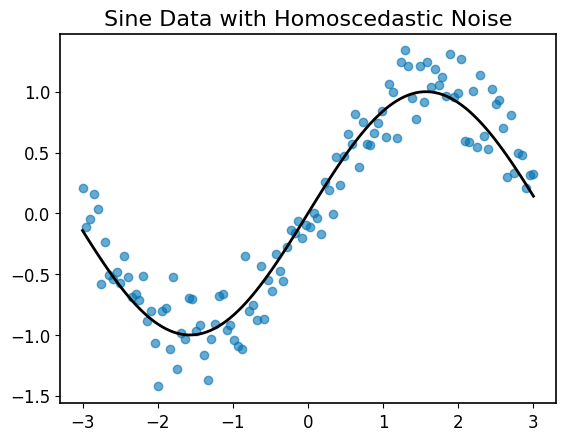

In [2]:
np.random.seed(0)

N = 120
x = np.linspace(-3, 3, N).reshape(-1, 1)
y_true = np.sin(x)

sigma_true = 0.2
y = y_true + np.random.normal(0, sigma_true, size=y_true.shape)

plt.scatter(x, y, alpha=0.6)
plt.plot(x, y_true, color="black", linewidth=2)
plt.title("Sine Data with Homoscedastic Noise")
plt.show()

In [3]:
import pymc as pm
import pytensor.tensor as pt

In [4]:
x_data = x.astype("float32")
y_data = y.flatten().astype("float32")

n_hidden = 20

In [5]:
with pm.Model() as bnn:
    x_shared = pm.Data("x_shared", x_data)

    # First layer
    w1 = pm.Normal("w1", 0, 1, shape=(1, n_hidden))
    b1 = pm.Normal("b1", 0, 1, shape=(n_hidden,))

    # Output layer
    w2 = pm.Normal("w2", 0, 1, shape=(n_hidden,))
    b2 = pm.Normal("b2", 0, 1)

    # # Global observation noise
    sigma = pm.HalfNormal("sigma", 1.0)

    # Forward pass
    hidden = pt.tanh(pt.dot(x_shared, w1) + b1)
    mu = pt.dot(hidden, w2) + b2

    # Likelihood
    # y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma_true, observed=y_data, shape=x_shared.shape[0])
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data, shape=x_shared.shape[0])

    trace = pm.sample(2000, tune=2000, target_accept=0.95)

Initializing NUTS using jitter+adapt_diag...
/home/alebab/development/Grokking-Bayes/.venv/lib/python3.10/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w1, b1, w2, b2, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 211 seconds.


In [7]:
x_test = np.linspace(-5, 5, 101).reshape(-1, 1)
y_test = np.sin(x_test)

In [8]:
with bnn:
    bnn.set_data("x_shared", x_test.astype("float32"))
    posterior_pred = pm.sample_posterior_predictive(trace)

Sampling: [y_obs]


Output()

In [9]:
y_samples = posterior_pred.posterior_predictive["y_obs"].data

pred_mean = y_samples.mean(axis=(0, 1))
pred_std = y_samples.std(axis=(0, 1))

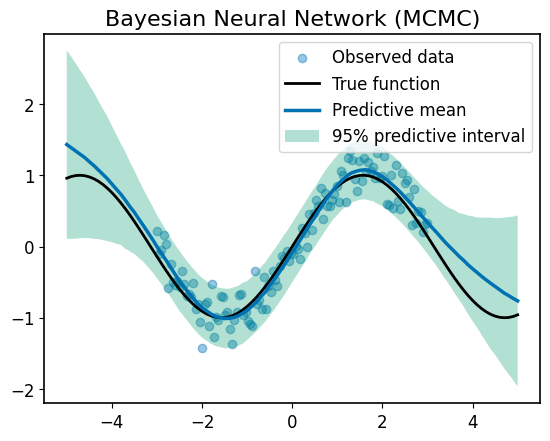

In [10]:
plt.scatter(x, y, alpha=0.4, label="Observed data")
plt.plot(x_test, y_test, color="black", linewidth=2, label="True function")

plt.plot(x_test, pred_mean, label="Predictive mean")
plt.fill_between(
    x_test.flatten(),
    pred_mean - 2*pred_std,
    pred_mean + 2*pred_std,
    alpha=0.3,
    label="95% predictive interval"
)

plt.legend()
plt.title("Bayesian Neural Network (MCMC)")
plt.show()

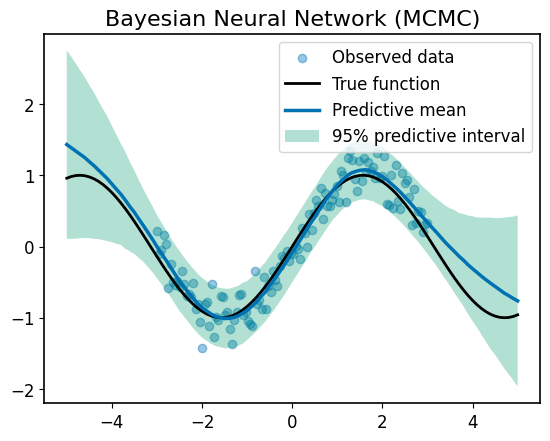

In [11]:
plt.scatter(x, y, alpha=0.4, label="Observed data")
plt.plot(x_test, y_test, color="black", linewidth=2, label="True function")

plt.plot(x_test, pred_mean, label="Predictive mean")
plt.fill_between(
    x_test.flatten(),
    pred_mean - 2*pred_std,
    pred_mean + 2*pred_std,
    alpha=0.3,
    label="95% predictive interval"
)

plt.legend()
plt.title("Bayesian Neural Network (MCMC)")
plt.show()